# Notebook 02 — YOLOv8 Inference & Evaluation

YOLOv8: real-time object detection without transformers — understanding the architecture, running inference, and evaluating with mAP and IoU.

**Table of Contents**
1. [YOLOv8 Architecture](#part-1)
2. [Anchor-Free Detection](#part-2)
3. [Running Inference](#part-3)
4. [Evaluation Metrics — IoU and mAP](#part-4)
5. [DETR vs YOLOv8 Comparison](#part-5)

---

<a id='part-1'></a>
## Part 1 — YOLOv8 Architecture

**YOLO = "You Only Look Once"** — the key insight is that detection happens in a single forward pass through the network. No region proposals, no two-stage pipeline. One pass, done.

Compare that to DETR (notebook 01): DETR is also a single forward pass, but it uses a Transformer encoder-decoder to reason globally about the whole image before predicting boxes. YOLOv8 stays entirely in CNN-land — faster, simpler, and easier to deploy on-device.

```
Input Image (640×640)
    ↓
Backbone (CSPDarknet)     ← hierarchical CNN, extracts features at multiple scales
    ↓
Neck (PANet / FPN)        ← combines features from different scales (small + large objects)
    ↓
Detection Head (×3)       ← predicts boxes at 3 scales: 80×80, 40×40, 20×20 grid cells
    ↓
Post-processing (NMS)     ← removes duplicate boxes (unlike DETR which needs no NMS)
```

**The three components:**

- **Backbone (CSPDarknet):** A convolutional network that reads the image and extracts progressively richer features — edges → textures → object parts → objects. CSP = Cross-Stage Partial connections, which reuse feature maps efficiently. Similar in spirit to the ResNet backbone in DETR, but tuned for speed.

- **Neck (PANet / FPN):** Feature Pyramid Network — takes features at multiple scales and mixes them. Deep features (small spatial, high semantic) are merged with shallow features (large spatial, low semantic). This lets the model detect both tiny objects (80×80 grid) and large objects (20×20 grid) with the same network.

- **Detection Head:** Three separate heads, one per scale. Each head outputs a grid of predictions. A cell in the 80×80 grid covers a small patch of the image — good for small objects. A cell in the 20×20 grid covers a large patch — good for large objects.

**Key differences from DETR:**

| | DETR | YOLOv8 |
|---|---|---|
| Backbone | ResNet + Transformer | CSPDarknet (CNN only) |
| Detection mechanism | 100 global learned queries | Grid-based, 3 scales |
| Post-processing | No NMS needed | NMS required |
| Speed | ~28 FPS | ~160 FPS |
| Accuracy (COCO mAP) | ~42 AP | ~53 AP |
| Parameters (nano/base) | ~41M (ResNet-50) | ~3.2M (nano) |

The transformer in DETR gives it global context — every query can attend to every pixel. YOLOv8's CNN is local by design (convolutions have a receptive field), but its multi-scale neck partially compensates. The trade-off: DETR is more principled architecturally; YOLOv8 is faster and more practical.

<a id='part-2'></a>
## Part 2 — Anchor-Free Detection

This is one of the most important improvements in YOLOv8 over earlier YOLO versions.

**Old YOLO (v1–v5): anchor-based**

At each grid cell, the model predicts offsets *relative to pre-defined anchor boxes* — fixed aspect ratios (tall, wide, square) determined by clustering training data bounding boxes. Three anchors per cell × three scales = nine anchor templates across the image.

Problem: anchors are dataset-specific and require tuning. If your objects don't match the anchor shapes, performance drops.

**YOLOv8: anchor-free**

Each grid cell predicts the object's center and size *directly* — no anchors needed:

```
For each grid cell, the head outputs:
  (cx, cy)   — center of the object, relative to the cell
  (w, h)     — width and height, relative to image size
  conf       — objectness score: is there an object here?
  class[80]  — probability for each of the 80 COCO classes
```

**Connection to DETR:** DETR *also* predicts `(cx, cy, w, h)` normalized to `[0, 1]`. Same output format — completely different mechanism. DETR uses 100 learned query embeddings that globally attend to the image and each output slot predicts one box or "no object". YOLOv8 uses dense grid predictions and filters with NMS.

**Why anchor-free is better:**
- No anchor hyperparameter tuning
- Generalizes better to unusual aspect ratios
- Simpler training target assignment
- YOLOv8 uses **Task-Aligned Assignment (TAL)** to decide which grid cells are responsible for which objects — replaces the old IoU-based anchor matching

**Connection to ViT (app-01):** In ViT, you patched the image into 16×16 tokens and processed them with attention. In YOLOv8, you can think of grid cells as a similar spatial decomposition — but instead of global attention across patches, each cell independently predicts based on local CNN features.

In [1]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import requests
import torch
from pathlib import Path

assets_dir = Path('../assets')
assets_dir.mkdir(exist_ok=True)

print(f'Torch: {torch.__version__}')
print(f'MPS available: {torch.backends.mps.is_available()}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/preetichauhan/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.10.0
MPS available: True


In [2]:
# YOLOv8n = nano (fastest, smallest), YOLOv8x = extra large (most accurate)
# pretrained on COCO 80 classes
model = YOLO('yolov8n.pt')
print(f'Model: YOLOv8n')
print(f'Parameters: {sum(p.numel() for p in model.model.parameters()):,}')
print(f'Classes: {len(model.names)} — {list(model.names.values())[:10]}...')

Model: YOLOv8n
Parameters: 3,157,200
Classes: 80 — ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']...


<a id='part-3'></a>
## Part 3 — Running Inference

YOLOv8 returns a `Results` object per image. The key attributes on `result.boxes`:

| Attribute | Shape | Description |
|---|---|---|
| `xyxy` | `(N, 4)` | Absolute pixel coordinates: `(x1, y1, x2, y2)` — top-left and bottom-right corners |
| `conf` | `(N,)` | Confidence score = objectness × class probability |
| `cls` | `(N,)` | Class index (integer, look up in `model.names`) |
| `xywhn` | `(N, 4)` | Normalized center format `(cx, cy, w, h)` in `[0,1]` — same format as DETR output |

The `conf=0.25` threshold in the `model()` call filters out low-confidence predictions before returning results. NMS has already been applied internally — you won't see duplicate boxes.

**What NMS does:** After the detection head outputs hundreds of candidate boxes (every grid cell at every scale), many overlap and refer to the same object. Non-Maximum Suppression keeps the highest-confidence box and suppresses any other box with IoU > 0.45 with it. DETR's set-prediction approach (Hungarian matching during training) is designed to avoid needing this step.

In [3]:
# Same image used in notebook 01 for direct comparison with DETR
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

results = model(image, conf=0.25, verbose=False)
result = results[0]

print(f'Detected {len(result.boxes)} objects')
for box in result.boxes:
    cls_name = model.names[int(box.cls)]
    conf = float(box.conf)
    coords = box.xyxy[0].tolist()
    print(f'  {cls_name}: {conf:.2f} at {[round(c) for c in coords]}')

Detected 5 objects
  cat: 0.89 at [341, 26, 640, 370]
  cat: 0.82 at [11, 54, 319, 471]
  remote: 0.78 at [40, 74, 177, 119]
  couch: 0.36 at [1, 0, 639, 480]
  remote: 0.32 at [335, 77, 371, 186]


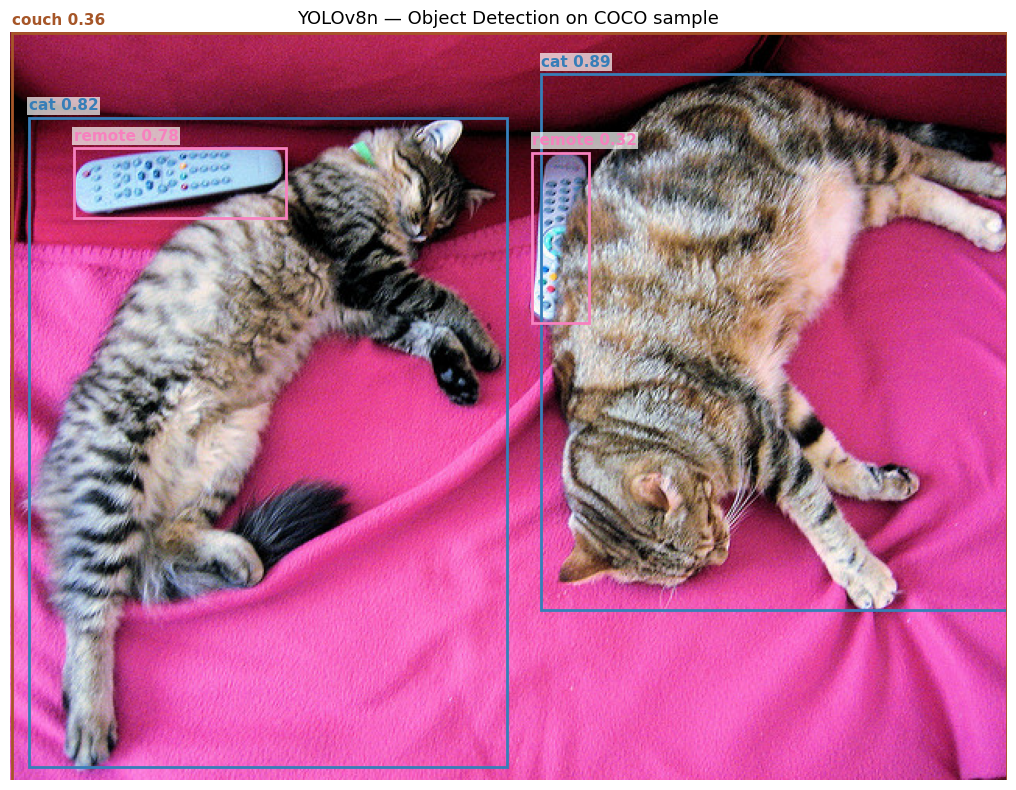

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(image)

colors = plt.cm.Set1(np.linspace(0, 1, len(model.names)))

for box in result.boxes:
    cls_id = int(box.cls)
    cls_name = model.names[cls_id]
    conf = float(box.conf)
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    
    color = colors[cls_id % len(colors)]
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1-5, f'{cls_name} {conf:.2f}', color=color, fontsize=11,
            fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

ax.axis('off')
ax.set_title('YOLOv8n — Object Detection on COCO sample', fontsize=13)
plt.tight_layout()
plt.savefig(assets_dir / 'yolo_detection.png', dpi=120, bbox_inches='tight')
plt.show()

<a id='part-4'></a>
## Part 4 — Evaluation Metrics: IoU and mAP

In app-01 (ViT classifier), you used **accuracy**: what fraction of images did the model classify correctly? That works when each image has one label.

Detection is harder to evaluate. Each image can have multiple objects. The model might find 5 of 6 objects, or find all 6 but place one box poorly. You need metrics that capture both *finding* objects and *locating* them precisely.

---

### IoU — Intersection over Union

IoU measures how well a predicted box overlaps a ground-truth box.

```
IoU = Area of Overlap / Area of Union

  ┌──────────────┐
  │  Predicted   │
  │    ┌─────────┼──────┐
  │    │ Overlap │      │
  └────┼─────────┘      │
       │  Ground Truth  │
       └────────────────┘

IoU = 1.0  → perfect prediction (boxes are identical)
IoU = 0.5  → common threshold: "close enough" to count as a correct detection
IoU = 0.0  → no overlap at all
```

A prediction is a **True Positive (TP)** if IoU ≥ threshold (commonly 0.5) and the class matches. Otherwise it's a **False Positive (FP)**. Ground-truth objects with no matching prediction are **False Negatives (FN)**.

**Connection to DETR:** IoU is also used inside DETR's Hungarian matching loss during training — the bipartite matching cost includes an IoU term to pair predicted queries with ground-truth boxes.

---

### Precision and Recall

```
Precision = TP / (TP + FP)   ← of all boxes I predicted, what fraction were correct?
Recall    = TP / (TP + FN)   ← of all ground-truth objects, what fraction did I find?
```

There's always a trade-off. Lower the confidence threshold → find more objects (higher recall) → but also more false alarms (lower precision).

---

### AP — Average Precision

To summarize the precision-recall trade-off into one number:
- Sweep the confidence threshold from 1.0 down to 0.0 — at each step compute precision and recall
- Plot the Precision-Recall curve
- **AP = area under that curve** (for one class)

AP is computed at a specific IoU threshold:
- **AP@0.5**: a prediction counts as TP if IoU ≥ 0.5 (lenient — box just needs to roughly overlap)
- **AP@0.75**: IoU ≥ 0.75 (stricter — box must be fairly accurate)
- **AP@0.5:0.95**: average of AP at IoU thresholds 0.50, 0.55, 0.60, ..., 0.95 — this is the **primary COCO metric**

---

### mAP — mean Average Precision

```
mAP = (1/C) × Σ AP_c    for each class c in 1..C
```

Average AP across all 80 COCO classes. A model that's great at detecting cars but misses bicycles will have lower mAP than one that's consistent across all classes.

**Reference numbers:**
- YOLOv8n: **~37 mAP@0.5:0.95**, ~53 mAP@0.5
- DETR (ResNet-50): **~42 mAP@0.5:0.95**
- YOLOv8x (extra-large): **~53 mAP@0.5:0.95**

The nano model trades accuracy for speed and size — exactly the right trade-off for on-device iPhone inference.

IoU: 0.681


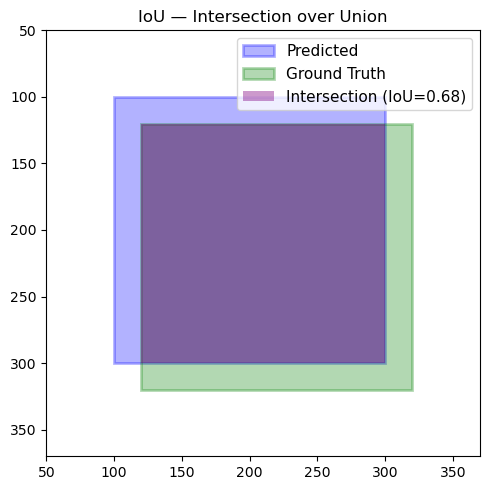

In [5]:
def compute_iou(box1, box2):
    """
    Compute IoU between two boxes in (x1, y1, x2, y2) format.
    Same metric used during DETR's Hungarian matching and YOLOv8 NMS.
    """
    # Intersection
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    # Union
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

# Example
pred_box = [100, 100, 300, 300]
gt_box   = [120, 120, 320, 320]
iou = compute_iou(pred_box, gt_box)
print(f'IoU: {iou:.3f}')

# Visualize
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(50, 370)
ax.set_ylim(50, 370)
ax.add_patch(patches.Rectangle((100, 100), 200, 200, linewidth=2,
                                 edgecolor='blue', facecolor='blue', alpha=0.3, label='Predicted'))
ax.add_patch(patches.Rectangle((120, 120), 200, 200, linewidth=2,
                                 edgecolor='green', facecolor='green', alpha=0.3, label='Ground Truth'))
ax.add_patch(patches.Rectangle((120, 120), 180, 180, linewidth=0,
                                 facecolor='purple', alpha=0.4, label=f'Intersection (IoU={iou:.2f})'))
ax.legend(fontsize=11)
ax.set_title('IoU — Intersection over Union', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(assets_dir / 'iou_diagram.png', dpi=120, bbox_inches='tight')
plt.show()

<a id='part-5'></a>
## Part 5 — DETR vs YOLOv8 Side by Side

Same image, same confidence threshold — let's see what each model actually detects.

What to look for:
- **Box tightness:** YOLOv8 tends to produce tighter boxes; DETR sometimes over-extends
- **Detection count:** DETR with threshold=0.7 is conservative; YOLOv8 at conf=0.25 is more permissive
- **Small objects:** YOLOv8's multi-scale head handles small objects well; DETR's global attention is also strong here
- **Speed:** You'll notice DETR takes noticeably longer to load and run even in a notebook context

/Users/preetichauhan/anaconda3/envs/codingenv/lib/python3.11/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/Users/preetichauhan/anaconda3/envs/codingenv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.mod

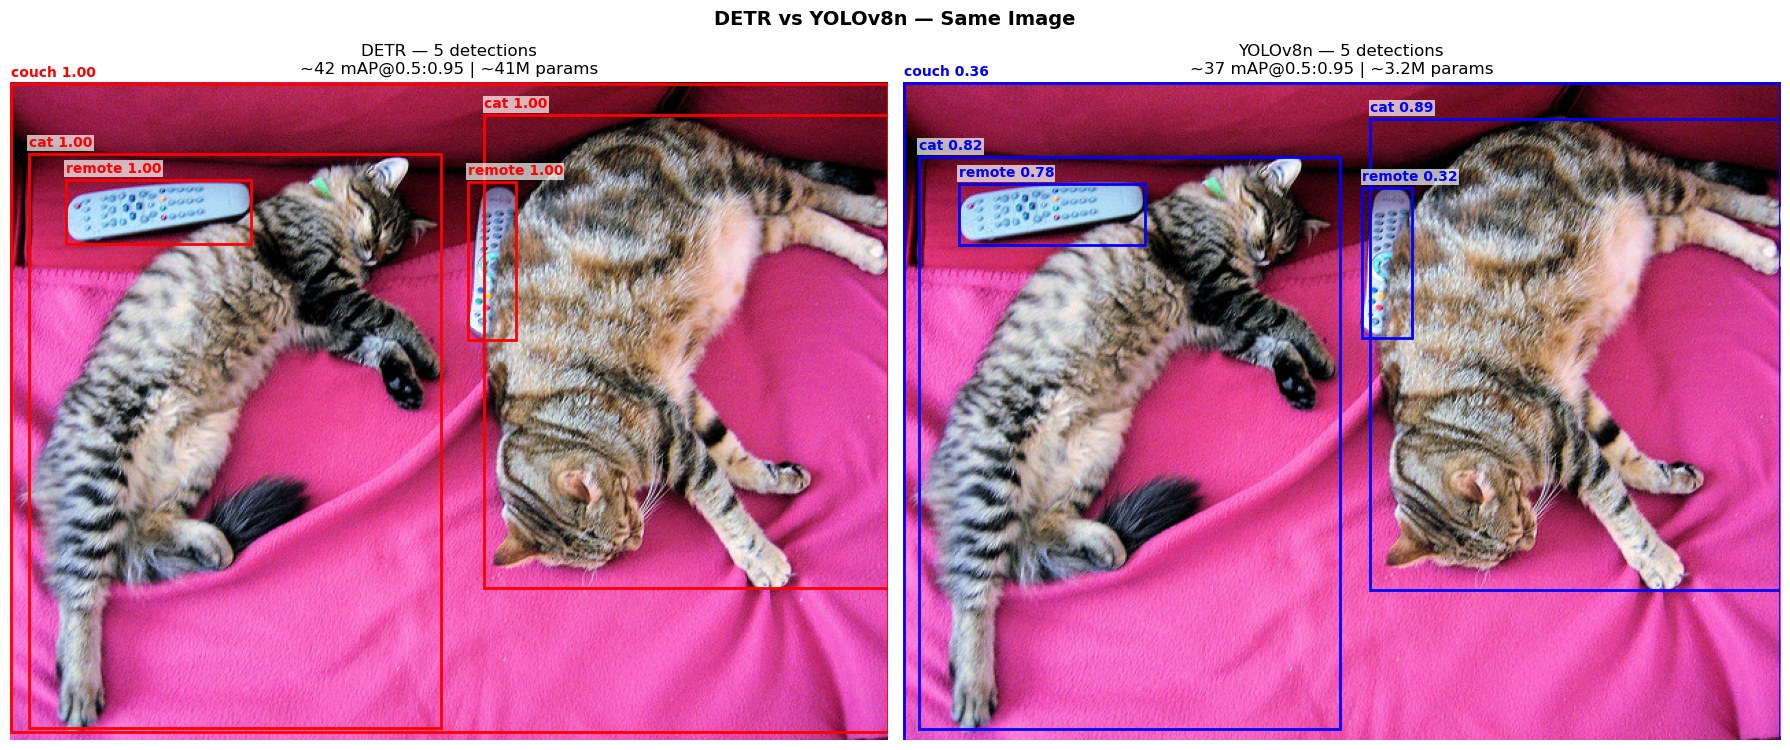

In [6]:
# Load DETR results (from notebook 01 — reload model)
from transformers import DetrImageProcessor, DetrForObjectDetection
import torch

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
processor_detr = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model_detr = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50").to(device).eval()

inputs = processor_detr(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    outputs_detr = model_detr(**inputs)
target_sizes = torch.tensor([image.size[::-1]]).to(device)
detr_results = processor_detr.post_process_object_detection(
    outputs_detr, target_sizes=target_sizes, threshold=0.7
)[0]

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# DETR
ax1.imshow(image)
for score, label, box in zip(detr_results["scores"], detr_results["labels"], detr_results["boxes"]):
    box = box.cpu().numpy()
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                               linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    label_name = model_detr.config.id2label[label.item()]
    ax1.text(box[0], box[1]-5, f'{label_name} {score:.2f}', color='red', fontsize=10,
             fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
ax1.set_title(f'DETR — {len(detr_results["scores"])} detections\n~42 mAP@0.5:0.95 | ~41M params', fontsize=12)
ax1.axis('off')

# YOLOv8
ax2.imshow(image)
for box in result.boxes:
    cls_name = model.names[int(box.cls)]
    conf = float(box.conf)
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2, edgecolor='blue', facecolor='none')
    ax2.add_patch(rect)
    ax2.text(x1, y1-5, f'{cls_name} {conf:.2f}', color='blue', fontsize=10,
             fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
ax2.set_title(f'YOLOv8n — {len(result.boxes)} detections\n~37 mAP@0.5:0.95 | ~3.2M params', fontsize=12)
ax2.axis('off')

plt.suptitle('DETR vs YOLOv8n — Same Image', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(assets_dir / 'detr_vs_yolo.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary

**What you built in this notebook:**
- Loaded YOLOv8n and ran inference on a COCO image
- Implemented IoU from scratch — the fundamental metric underlying all detection evaluation
- Compared DETR and YOLOv8 side by side on the same image

**Key takeaways:**

- YOLOv8 is faster and lighter than DETR — 3.2M vs 41M params, ~160 FPS vs ~28 FPS
- DETR is architecturally cleaner — no NMS, pure set prediction via Hungarian matching
- Both output `(class, confidence, bounding box)` — the difference is entirely in how they get there: global transformer attention vs local grid-based CNN
- mAP is the standard detection metric — it combines precision, recall, and localization accuracy (via IoU) across all classes and confidence thresholds
- For on-device iPhone deployment, YOLOv8 is the right choice: speed, small model size, and native CoreML export support

**Architecture lineage across your three models:**

| Model | Spatial processing | Global context | Output |
|---|---|---|---|
| ViT (app-01) | Patch embeddings | Self-attention (all patches) | Single class label |
| DETR (nb-01) | CNN patches → positional encoding | Cross-attention (100 queries × all patches) | 100 box predictions |
| YOLOv8 (this) | CNN feature pyramid | None (local convolutions only) | Dense grid predictions + NMS |

---

**Next → Notebook 03:** Visualization deep dive — drawing boxes, confidence filtering, NMS explained visually, and preparing for CoreML export.

[↑ Back to top](#notebook-02----yolov8-inference--evaluation)

---